# TF Motif Analysis — Hepatocyte Peak-TF Match Map

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/data1/project/yeonu/065_multi_atac/TFmotif/results_output/Hepatocyte_Peak_TF_Match_Map.csv")
df.head()

,peak,motif_id,is_bound,tf_name,avg_log2FC,p_val_adj,pwm_score,pwm_threshold,pwm_max
0,chr3-31377120-31377319,MA0030.1,True,FOXF2,5.342173,4.357820e-15,12.781030,6.976204,19.277838
1,chr1-184626317-184626915,MA0030.1,True,FOXF2,2.182091,5.864476e-10,8.025777,6.976204,19.277838
2,chr1-203538023-203538499,MA0030.1,True,FOXF2,2.364209,1.891556e-09,10.510062,6.976204,19.277838
3,chr1-178724685-178726528,MA0030.1,True,FOXF2,1.365042,1.283329e-08,8.831577,6.976204,19.277838
4,chr2-241881167-241882390,MA0030.1,True,FOXF2,1.755156,3.558630e-07,9.247428,6.976204,19.277838


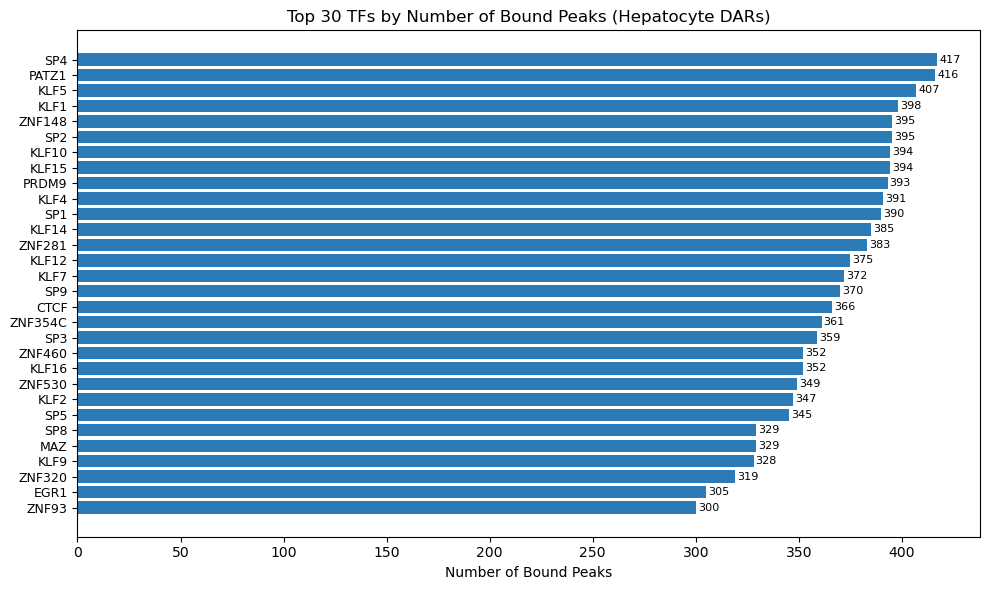

In [2]:
# Top TFs Bar Plot — 결합된 Peak 수 기준 상위 TF
tf_peak_count = df.groupby('tf_name')['peak'].nunique().sort_values(ascending=False)
top_n = 30
top_tfs = tf_peak_count.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_tfs)), top_tfs.values, color='#2c7bb6')
ax.set_yticks(range(len(top_tfs)))
ax.set_yticklabels(top_tfs.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of Bound Peaks')
ax.set_title(f'Top {top_n} TFs by Number of Bound Peaks (Hepatocyte DARs)')
for i, v in enumerate(top_tfs.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

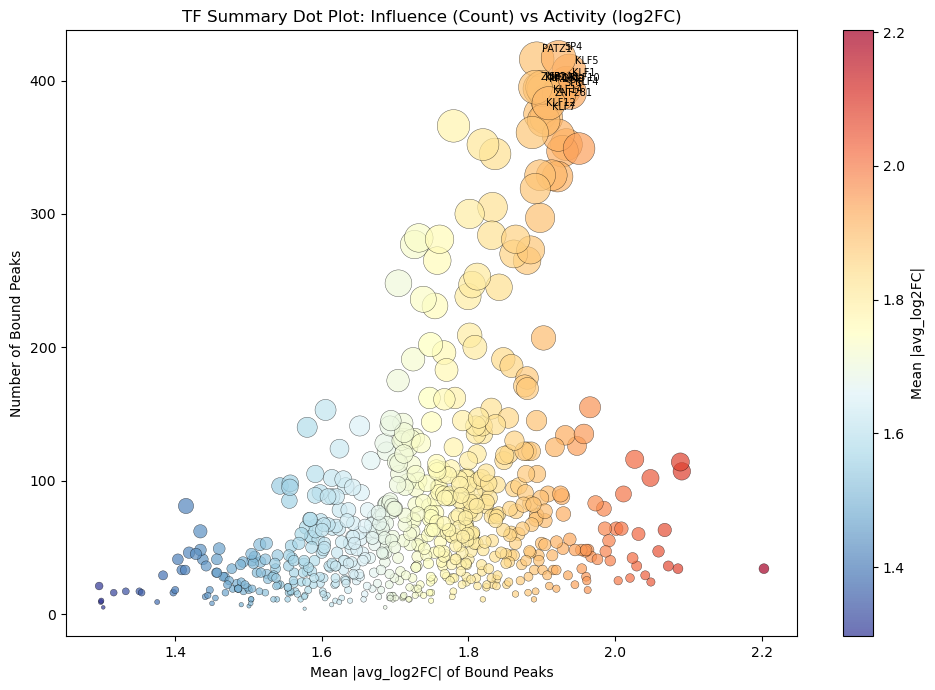

In [3]:
# TF Summary Dot Plot — Count (영향력) vs mean |log2FC| (활성도)
tf_summary = df.groupby('tf_name').agg(
    peak_count=('peak', 'nunique'),
    mean_abs_log2FC=('avg_log2FC', lambda x: np.mean(np.abs(x)))
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    tf_summary['mean_abs_log2FC'],
    tf_summary['peak_count'],
    s=tf_summary['peak_count'] * 1.5,
    c=tf_summary['mean_abs_log2FC'],
    cmap='RdYlBu_r', alpha=0.7, edgecolors='k', linewidths=0.3
)
plt.colorbar(sc, label='Mean |avg_log2FC|')
ax.set_xlabel('Mean |avg_log2FC| of Bound Peaks')
ax.set_ylabel('Number of Bound Peaks')
ax.set_title('TF Summary Dot Plot: Influence (Count) vs Activity (log2FC)')

top_label = tf_summary.nlargest(15, 'peak_count')
for _, row in top_label.iterrows():
    ax.annotate(row['tf_name'], (row['mean_abs_log2FC'], row['peak_count']),
                fontsize=7, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')
plt.tight_layout()
plt.show()

# TF Activity Analysis — chromVAR Z-scores (TC Hepatocytes)

In [4]:
# 데이터 로드
tf_activity = pd.read_csv("/data1/project/yeonu/065_multi_atac/TFmotif/results_output/Hepatocyte_TF_activity.csv", index_col=0)
metadata = pd.read_csv("/data1/project2/yeonu/cirrhosis/multiome/rna_cell_metadata.csv", index_col=0)

# motif ID → TF name 매핑 테이블
motif_tf = df[['motif_id', 'tf_name']].drop_duplicates().set_index('motif_id')['tf_name']

# TF activity index를 TF 이름으로 변환 (중복 motif → 같은 TF는 평균)
tf_activity.index = tf_activity.index.map(lambda x: motif_tf.get(x, x))
tf_activity = tf_activity.groupby(tf_activity.index).mean()

# 공통 세포 & status 매핑
common_cells = tf_activity.columns.intersection(metadata.index)
tf_activity = tf_activity[common_cells]
cell_status = metadata.loc[common_cells, 'status']

print(f"TF activity: {tf_activity.shape[0]} TFs × {tf_activity.shape[1]} cells")
print(f"Status distribution:\n{cell_status.value_counts()}")

TF activity: 647 TFs × 2734 cells
Status distribution:
status
Hepatitis    2559
Cirrhosis     175
Name: count, dtype: int64


/data1/project/yeonu/Anaconda3/envs/viz/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


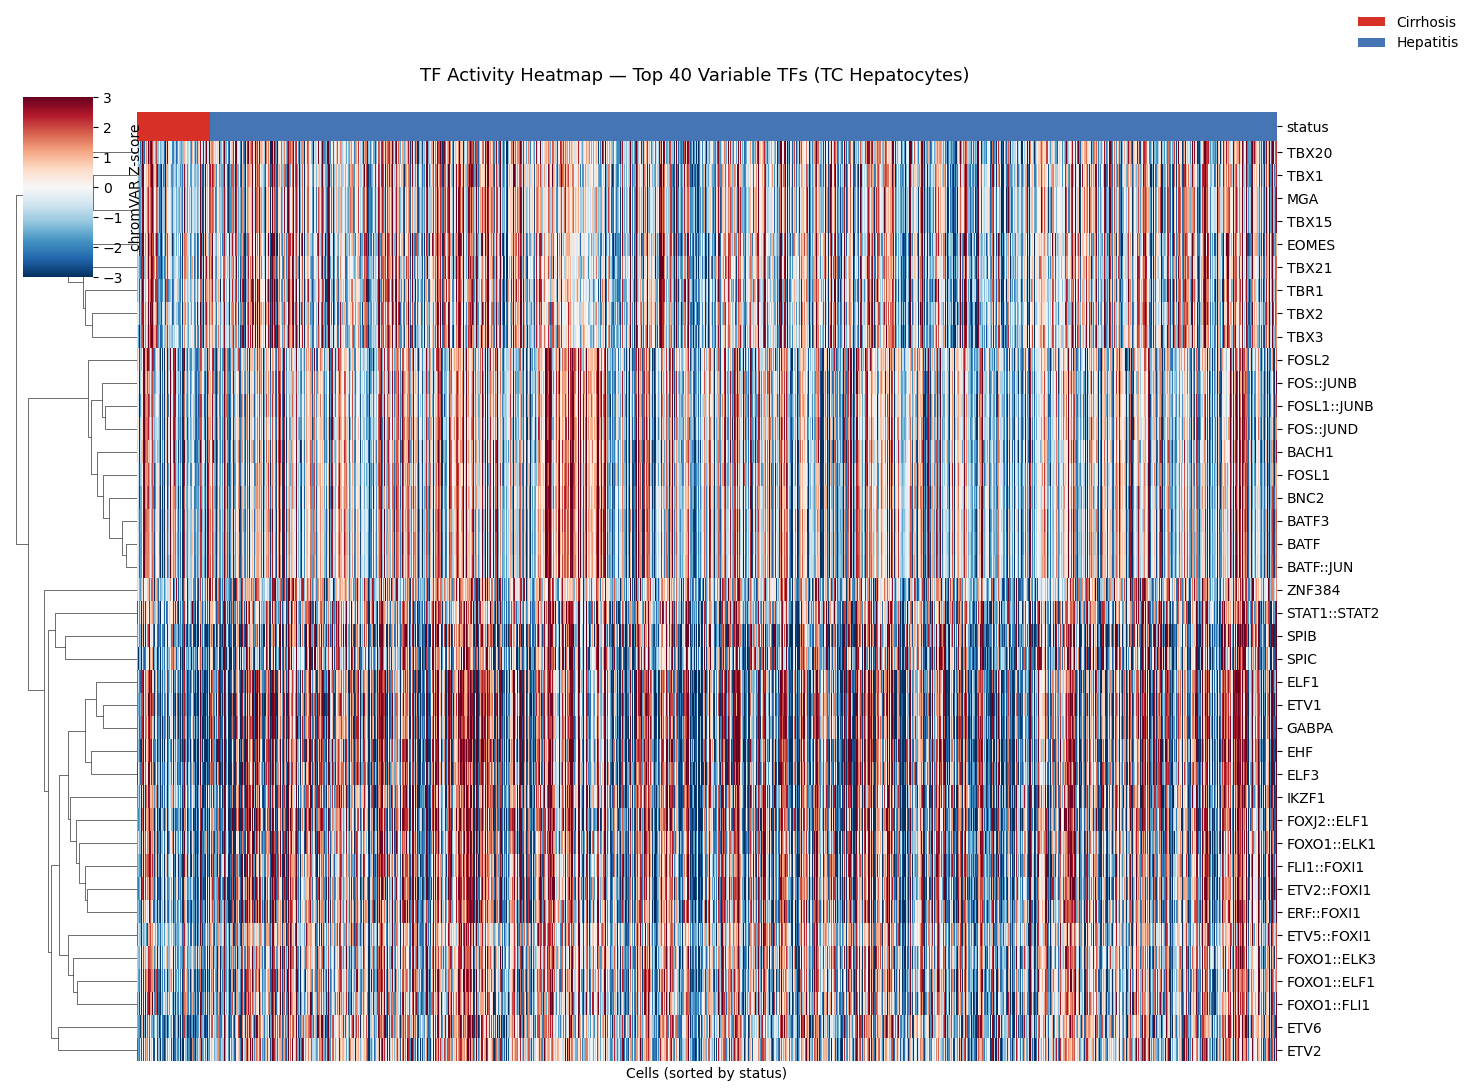

In [5]:
# 1. TF Activity Heatmap — 상위 변동 TF × 세포 (status별 정렬)
import seaborn as sns

# 변동성 상위 TF 선택 (표준편차 기준)
tf_var = tf_activity.var(axis=1).sort_values(ascending=False)
top_tfs_heatmap = tf_var.head(40).index

# status별로 세포 정렬 (Cirrhosis | Hepatitis)
sorted_cells = cell_status.sort_values().index
mat = tf_activity.loc[top_tfs_heatmap, sorted_cells]

# Z-score clipping (시각화를 위해 ±3 범위)
mat_clipped = mat.clip(-3, 3)

# 상단 annotation bar (status 색상)
status_colors = {'Cirrhosis': '#d73027', 'Hepatitis': '#4575b4'}
col_colors = cell_status.loc[sorted_cells].map(status_colors)

g = sns.clustermap(
    mat_clipped,
    cmap='RdBu_r', center=0, vmin=-3, vmax=3,
    row_cluster=True, col_cluster=False,
    col_colors=col_colors,
    yticklabels=True, xticklabels=False,
    figsize=(14, 10),
    cbar_kws={'label': 'chromVAR Z-score', 'shrink': 0.5},
    dendrogram_ratio=(0.1, 0.02)
)
g.ax_heatmap.set_xlabel('Cells (sorted by status)')
g.ax_heatmap.set_ylabel('')
g.fig.suptitle('TF Activity Heatmap — Top 40 Variable TFs (TC Hepatocytes)', y=1.01, fontsize=13)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in status_colors.items()]
g.ax_heatmap.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.06, 1.15), frameon=False)
plt.show()

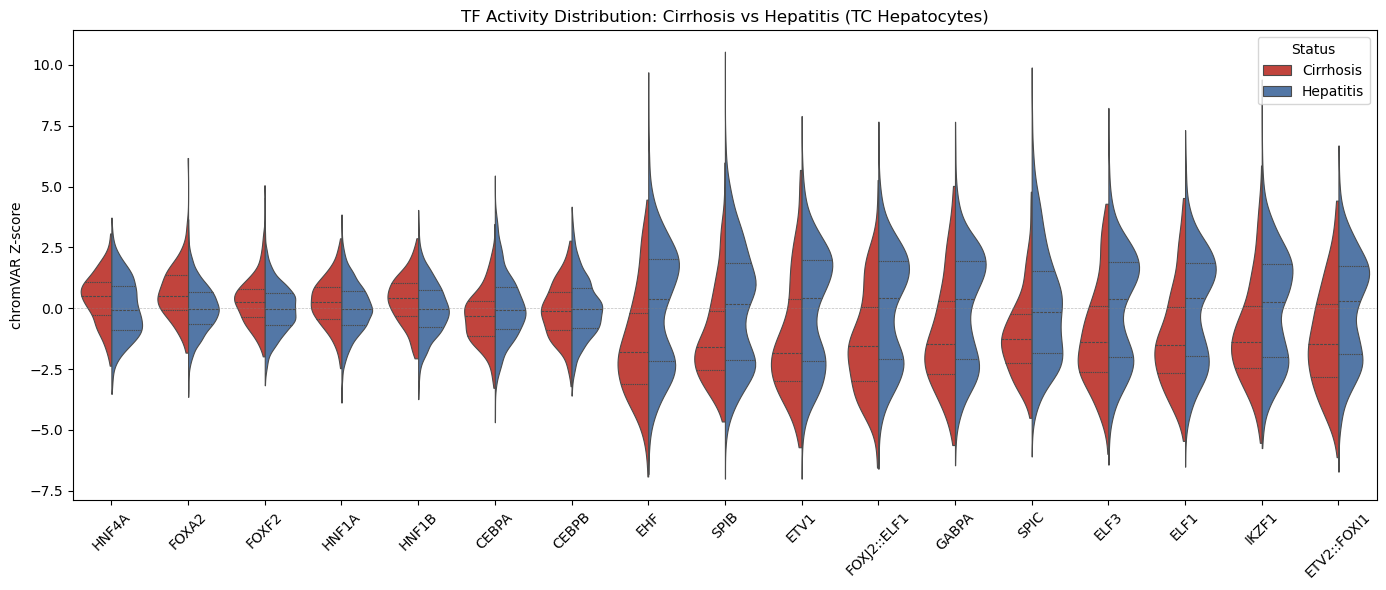

In [6]:
# 2. TF Activity Distribution — Violin Plot (Cirrhosis vs Hepatitis)
known_tfs = ['HNF4A', 'FOXA2', 'FOXF2', 'HNF1A', 'HNF1B', 'CEBPA', 'CEBPB']
top_var_tfs = tf_var.head(10).index.tolist()
plot_tfs = list(dict.fromkeys(known_tfs + top_var_tfs))
plot_tfs = [t for t in plot_tfs if t in tf_activity.index]

plot_data = tf_activity.loc[plot_tfs, common_cells].T.copy()
plot_data['status'] = cell_status.values
plot_long = plot_data.melt(id_vars='status', var_name='TF', value_name='Z-score')

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(
    data=plot_long, x='TF', y='Z-score', hue='status',
    split=True, inner='quart', linewidth=0.8,
    palette={'Cirrhosis': '#d73027', 'Hepatitis': '#4575b4'},
    ax=ax, density_norm='width', cut=0
)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_title('TF Activity Distribution: Cirrhosis vs Hepatitis (TC Hepatocytes)')
ax.set_xlabel('')
ax.set_ylabel('chromVAR Z-score')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Status', loc='upper right')
plt.tight_layout()
plt.show()